In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
acceptances = pd.read_excel("../data/cleaned/acceptances/acceptances.xlsx")

In [11]:
bandages = pd.read_excel("../data/cleaned/acceptances/bandages.xlsx")

In [ ]:
bandages = pd.read_excel("../data/cleaned/acceptances/bandages.xlsx")

In [6]:
results = pd.read_csv("../data/raw/results/runners.csv")

C:\Users\sriva\AppData\Local\Temp\ipykernel_10504\1325582542.py:1: DtypeWarning: Columns (0: sire_nat, 1: dam_nat, 2: weight) have mixed types. Specify dtype option on import or set low_memory=False.
  results = pd.read_csv("../data/raw/results/runners.csv")


In [12]:
results["meet_date"] = pd.to_datetime(results["meet_date"])
acceptances["meet_date"] = pd.to_datetime(acceptances["meet_date"])
bandages["meet_date"] = pd.to_datetime(bandages["meet_date"])

In [19]:
combined = pd.merge(
    results,
    bandages,
    on=["meet_date", "horse_name"],
    how="inner"
)

In [20]:
combined.head()

,meet_date,venue,race_no_x,placing,horse_name,horse_seq,sire,sire_nat,dam,dam_nat,weight,jockey,jockey_claim,trainer,odds,finish_time,horse_body_wt,race_no_y,bandage_type
0,2018-01-04,Mumbai,100,3,BOLD MARCH,16211,Arazan,NaN,Warsaw Pact,NaN,53.0,S. Zervan,NaN,Karthik Ganapathy,13/4,1:38:636,492,1,BF
1,2018-01-04,Mumbai,100,5,REMEMBER ME,14814,Ikhtyar,NaN,Enaksi,NaN,57.5,S. A. Amit,1.5,Nirad Karanjawala,25/1,1:39:315,414,1,BF
2,2018-01-04,Mumbai,102,2,CONGRESSIONAL,15152,Razeen,NaN,Kerataka,NaN,58.5,A. Imran Khan,NaN,Bezan Chenoy,14/1,1:23:658,508,3,BH
3,2018-01-04,Mumbai,102,3,SHIP ROCK,16094,Kingda Ka,NaN,Giacosa,NaN,59.0,David Probert,NaN,Vishal Gaikwad,13/2,1:24:795,493,3,BF
4,2018-01-04,Mumbai,102,4,BRYNHILL,14273,Noverre,NaN,Chain Reaction,NaN,61.0,Santosh G.,1.5,Nazak Chenoy,30/1,1:26:552,441,3,BF


In [29]:
import pandas as pd

counts = combined.pivot_table(
    index="placing",
    columns="bandage_type",
    aggfunc="size",
    fill_value=0
)

# convert to numeric where possible
numeric_index = pd.to_numeric(counts.index, errors="coerce")

numeric_counts = counts[numeric_index.notna()].copy()
numeric_counts.index = numeric_index[numeric_index.notna()].astype(int)
numeric_counts = numeric_counts.sort_index()

non_numeric_counts = counts[numeric_index.isna()]

final_counts = pd.concat([numeric_counts, non_numeric_counts])
print(final_counts)

bandage_type  AF   BF   BH
placing                   
1             63  298   71
2             57  351  102
3             75  339  107
4             67  414  120
5             69  370   99
6             59  340  129
7             45  342   82
8             41  288   95
9             34  236   86
10            21  193   47
11            18  161   39
12             8  101   36
13             8   55   22
14             9   42   12
15             1    8    5
16             1    1    1
DNC            6   18    6
DNF            5   20    1
DQ             2    1    0
NDS            1    3    1
NPR            0    2    0
WD             5   51   14
WDRN           9   42    3


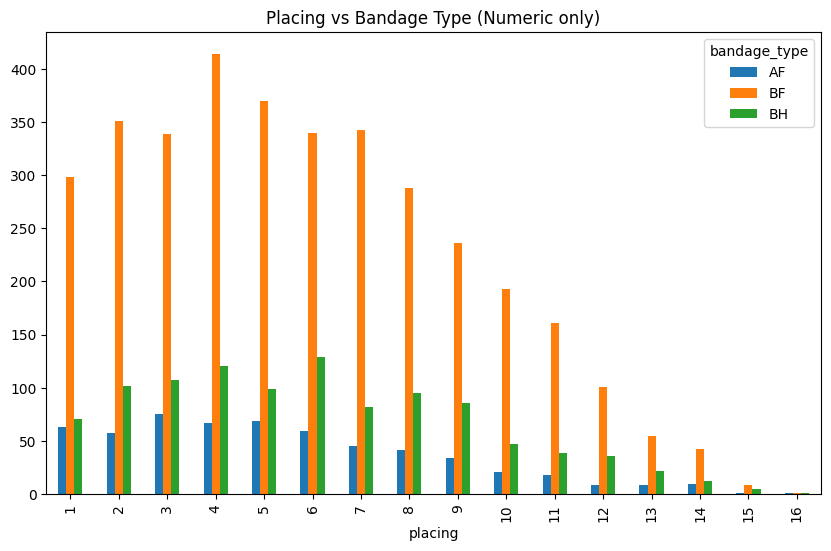

In [30]:
numeric_counts.plot(kind="bar", figsize=(10,6))
plt.title("Placing vs Bandage Type (Numeric only)")
plt.show()

In [39]:
print(numeric_counts)

bandage_type  AF   BF   BH
placing                   
1             63  298   71
2             57  351  102
3             75  339  107
4             67  414  120
5             69  370   99
6             59  340  129
7             45  342   82
8             41  288   95
9             34  236   86
10            21  193   47
11            18  161   39
12             8  101   36
13             8   55   22
14             9   42   12
15             1    8    5
16             1    1    1


In [37]:
overall_dist = combined["bandage_type"].value_counts(normalize=True)
print(overall_dist)

bandage_type
BF    0.686077
BH    0.201194
AF    0.112729
Name: proportion, dtype: float64


In [38]:
def bucket(x):
    try:
        x = int(x)
        if x == 1:
            return "Win"
        elif x <= 3:
            return "Top3"
        elif x <= 10:
            return "Mid"
        else:
            return "Low"
    except:
        return "NonFinish"

combined["placing_group"] = combined["placing"].apply(bucket)

In [40]:
groups = combined["placing_group"].unique()

for g in groups:
    subset = combined[combined["placing_group"] == g]

    observed = subset["bandage_type"].value_counts(normalize=True)

    comparison = pd.DataFrame({
        "observed": observed,
        "expected": overall_dist
    }).fillna(0)

    comparison["diff"] = comparison["observed"] - comparison["expected"]

    print(f"\n--- {g} ---")
    print(comparison.sort_values("diff", ascending=False))


--- Top3 ---
              observed  expected      diff
bandage_type                              
AF            0.128031  0.112729  0.015302
BH            0.202716  0.201194  0.001521
BF            0.669253  0.686077 -0.016824

--- Mid ---
              observed  expected      diff
bandage_type                              
BH            0.207114  0.201194  0.005919
BF            0.687126  0.686077  0.001049
AF            0.105760  0.112729 -0.006968

--- NonFinish ---
              observed  expected      diff
bandage_type                              
BF            0.721053  0.686077  0.034976
AF            0.147368  0.112729  0.034640
BH            0.131579  0.201194 -0.069616

--- Win ---
              observed  expected      diff
bandage_type                              
AF            0.145833  0.112729  0.033105
BF            0.689815  0.686077  0.003738
BH            0.164352  0.201194 -0.036843

--- Low ---
              observed  expected      diff
bandage_type             

In [41]:
from scipy.stats import chisquare

for g in groups:
    subset = combined[combined["placing_group"] == g]

    observed = subset["bandage_type"].value_counts().sort_index()
    expected = overall_dist * len(subset)

    # align
    expected = expected.reindex(observed.index, fill_value=0)

    chi2, p = chisquare(f_obs=observed, f_exp=expected)

    print(g, "p-value:", p)

Top3 p-value: 0.27543284773607046
Mid p-value: 0.38157568575221573
NonFinish p-value: 0.03115030024460968
Win p-value: 0.028394317429964146
Low p-value: 0.11317137407303243


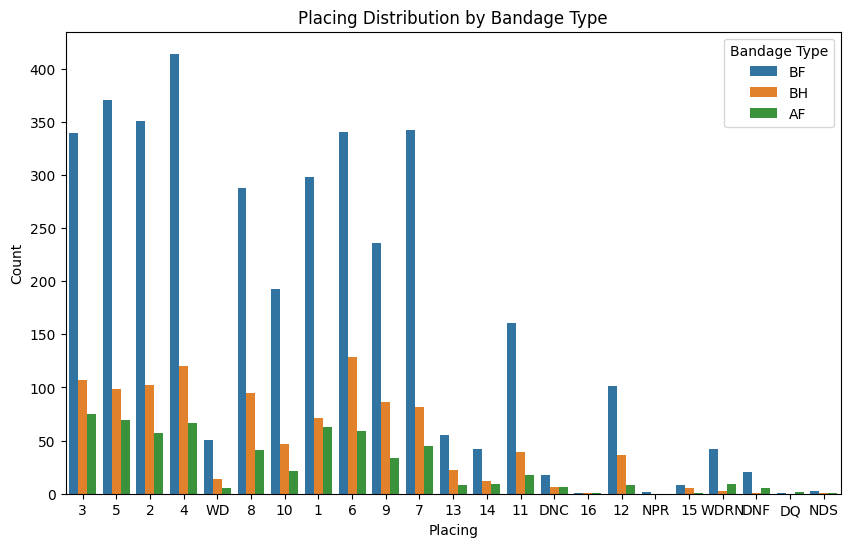

In [21]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=combined,
    x="placing",
    hue="bandage_type"
)

plt.title("Placing Distribution by Bandage Type")
plt.xlabel("Placing")
plt.ylabel("Count")
plt.legend(title="Bandage Type")

plt.show()